#sckit-fuzzyのインストール

In [ ]:
pip install -U scikit-fuzzy

     |████████████████████████████████| 993 kB 7.9 MB/s 
  Created wheel for scikit-fuzzy: filename=scikit_fuzzy-0.4.2-py3-none-any.whl size=894089 sha256=3f92584f85de1b478b5c72357037c862c4f0b139b5fa6e61e83502e65f4a5a57
  Stored in directory: /root/.cache/pip/wheels/d5/74/fc/38588a3d2e3f34f74588e6daa3aa5b0a322bd6f9420a707131
Successfully built scikit-fuzzy


#日本語用ライブラリのインストール

In [ ]:
pip install japanize_matplotlib

     |████████████████████████████████| 4.1 MB 7.5 MB/s 
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120274 sha256=37f93e7a1647b9fb7e976fff5444a0c8a3dffacaace6bc78f98ce8a75f1dfe9d
  Stored in directory: /root/.cache/pip/wheels/83/97/6b/e9e0cde099cc40f972b8dd23367308f7705ae06cd6d4714658
Successfully built japanize-matplotlib


#ライブラリのインポート

In [ ]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt #グラフ用
import japanize_matplotlib #日本語用
from IPython import display #表示用

#値の範囲の設定
温度：15～35

出力：0～100

※最大の値に1を足した値を設定します。

In [ ]:
x_temp = np.arange(15, 36, 1) #温度の範囲
x_power  = np.arange(0, 101, 1) #出力の範囲

#メンバシップ関数の定義

In [ ]:
#温度
temp_lo2 = fuzz.trimf(x_temp, [15,15,20])
temp_lo = fuzz.trimf(x_temp, [15,20,25])
temp_md = fuzz.trimf(x_temp, [20,25,30])
temp_hi = fuzz.trimf(x_temp, [25,30,35])
temp_hi2 = fuzz.trimf(x_temp, [30,35,35])
#出力
power_lo2 = fuzz.trimf(x_power, [0, 0, 25])
power_lo = fuzz.trimf(x_power, [0, 25, 50])
power_md = fuzz.trimf(x_power, [25, 50, 75])
power_hi = fuzz.trimf(x_power, [50, 75, 100])
power_hi2 = fuzz.trimf(x_power, [75, 100, 100])

#メンバシップ関数の可視化

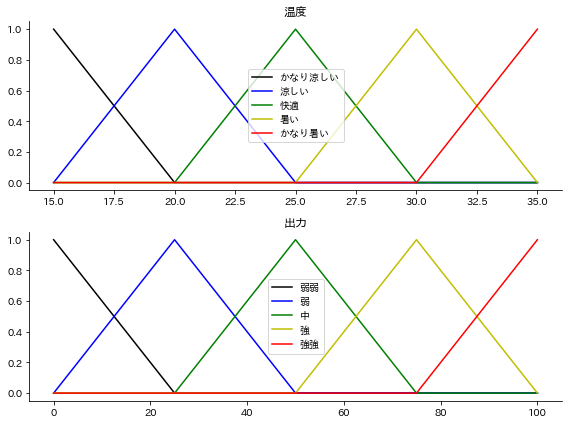

In [ ]:
#2つのグラフの設定
fig, (ax0, ax1) = plt.subplots(nrows=2, figsize=(8, 6))
#温度のおいしさのメンバシップ関数
ax0.plot(x_temp, temp_lo2, 'k', linewidth=1.5, label='かなり涼しい')
ax0.plot(x_temp, temp_lo, 'b', linewidth=1.5, label='涼しい')
ax0.plot(x_temp, temp_md, 'g', linewidth=1.5, label='快適')
ax0.plot(x_temp, temp_hi, 'y', linewidth=1.5, label='暑い')
ax0.plot(x_temp, temp_hi2, 'r', linewidth=1.5, label='かなり暑い')
ax0.set_title('温度')
ax0.legend()
#出力のおいしさのメンバシップ関数
ax1.plot(x_power, power_lo2, 'k', linewidth=1.5, label='弱弱')
ax1.plot(x_power, power_lo, 'b', linewidth=1.5, label='弱')
ax1.plot(x_power, power_md, 'g', linewidth=1.5, label='中')
ax1.plot(x_power, power_hi, 'y', linewidth=1.5, label='強')
ax1.plot(x_power, power_hi2, 'r', linewidth=1.5, label='強強')
ax1.set_title('出力')
ax1.legend()

#右と上の軸を削除
for ax in (ax0, ax1):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()

#現在の温度の設定

In [ ]:
now_temp = 28

#出力の決定（ファジー推論）

ルールは寒いは弱，適温は中，暑いは強にそれぞれ対応

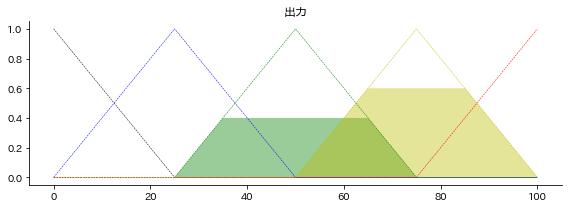

In [ ]:
#温度のグレードの計算
temp_level_lo2 = fuzz.interp_membership(x_temp, temp_lo2, now_temp)
temp_level_lo = fuzz.interp_membership(x_temp, temp_lo, now_temp)
temp_level_md = fuzz.interp_membership(x_temp, temp_md, now_temp)
temp_level_hi = fuzz.interp_membership(x_temp, temp_hi, now_temp)
temp_level_hi2 = fuzz.interp_membership(x_temp, temp_hi2, now_temp)

#各グレードと出力のメンバシップ関数の小さい方の範囲を設定
power_activation_lo2 = np.fmin(temp_level_lo2, power_lo2)
power_activation_lo = np.fmin(temp_level_lo, power_lo)
power_activation_md = np.fmin(temp_level_md, power_md) 
power_activation_hi = np.fmin(temp_level_hi, power_hi) 
power_activation_hi2 = np.fmin(temp_level_hi2, power_hi2)

#描画のために0の配列を作っておく
power0 = np.zeros_like(x_power)

#可視化
fig, ax0 = plt.subplots(figsize=(8, 3))

ax0.fill_between(x_power, power0, power_activation_lo2, facecolor='k', alpha=0.4)
ax0.plot(x_power, power_lo2, 'k', linewidth=0.5, linestyle='--', )
ax0.fill_between(x_power, power0, power_activation_lo, facecolor='b', alpha=0.4)
ax0.plot(x_power, power_lo, 'b', linewidth=0.5, linestyle='--', )
ax0.fill_between(x_power, power0, power_activation_md, facecolor='g', alpha=0.4)
ax0.plot(x_power, power_md, 'g', linewidth=0.5, linestyle='--')
ax0.fill_between(x_power, power0, power_activation_hi, facecolor='y', alpha=0.4)
ax0.plot(x_power, power_hi, 'y', linewidth=0.5, linestyle='--')
ax0.fill_between(x_power, power0, power_activation_hi2, facecolor='r', alpha=0.4)
ax0.plot(x_power, power_hi2, 'r', linewidth=0.5, linestyle='--')
ax0.set_title('出力')

#右と上の軸を削除
for ax in (ax0,):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()



#出力の決定（非ファジー化）

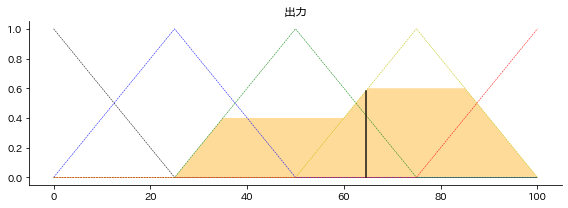

In [ ]:
# すべての範囲を統合
aggregated = np.fmax(power_activation_lo,
                     np.fmax(
                         np.fmax(power_activation_md, power_activation_hi),
                         np.fmax(power_activation_lo2, power_activation_hi2)))

# 非ファジー化（出力の計算）
power = fuzz.defuzz(x_power, aggregated, 'centroid')
power_activation = fuzz.interp_membership(x_power, aggregated, power)  # 描画用

#可視化
fig, ax0 = plt.subplots(figsize=(8, 3))

ax0.plot(x_power, power_lo2, 'k', linewidth=0.5, linestyle='--', )
ax0.plot(x_power, power_lo, 'b', linewidth=0.5, linestyle='--', )
ax0.plot(x_power, power_md, 'g', linewidth=0.5, linestyle='--')
ax0.plot(x_power, power_hi, 'y', linewidth=0.5, linestyle='--')
ax0.plot(x_power, power_hi2, 'r', linewidth=0.5, linestyle='--')
ax0.fill_between(x_power, power0, aggregated, facecolor='Orange', alpha=0.4)
ax0.plot([power, power], [0, power_activation], 'k', linewidth=1.5, alpha=0.9)
ax0.set_title('出力')

#右と上の軸を削除
for ax in (ax0,):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()

#出力の決定（ルールの記述＋ファジー推論＋非ファジー化）

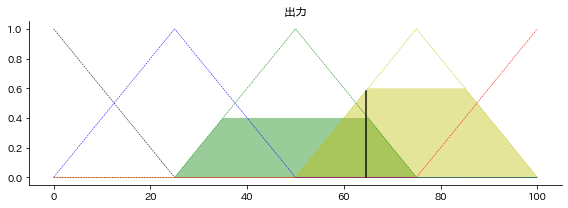

In [ ]:
#温度のグレードの計算
temp_level_lo2 = fuzz.interp_membership(x_temp, temp_lo2, now_temp)
temp_level_lo = fuzz.interp_membership(x_temp, temp_lo, now_temp)
temp_level_md = fuzz.interp_membership(x_temp, temp_md, now_temp)
temp_level_hi = fuzz.interp_membership(x_temp, temp_hi, now_temp)
temp_level_hi2 = fuzz.interp_membership(x_temp, temp_hi2, now_temp)

#各グレードと出力のメンバシップ関数の小さい方の範囲を設定
power_activation_lo2 = np.fmin(temp_level_lo2, power_lo2)
power_activation_lo = np.fmin(temp_level_lo, power_lo)
power_activation_md = np.fmin(temp_level_md, power_md) 
power_activation_hi = np.fmin(temp_level_hi, power_hi) 
power_activation_hi2 = np.fmin(temp_level_hi2, power_hi2)

# すべての範囲を統合
aggregated = np.fmax(power_activation_lo,
                     np.fmax(
                         np.fmax(power_activation_md, power_activation_hi),
                         np.fmax(power_activation_lo2, power_activation_hi2)))

# 非ファジー化（出力の計算）
power = fuzz.defuzz(x_power, aggregated, 'centroid')
power_activation = fuzz.interp_membership(x_power, aggregated, power)  # 描画用

#描画のために0の配列を作っておく
power0 = np.zeros_like(x_power)

#可視化
fig, ax0 = plt.subplots(figsize=(8, 3))

ax0.fill_between(x_power, power0, power_activation_lo2, facecolor='k', alpha=0.4)
ax0.plot(x_power, power_lo2, 'k', linewidth=0.5, linestyle='--', )
ax0.fill_between(x_power, power0, power_activation_lo, facecolor='b', alpha=0.4)
ax0.plot(x_power, power_lo, 'b', linewidth=0.5, linestyle='--', )
ax0.fill_between(x_power, power0, power_activation_md, facecolor='g', alpha=0.4)
ax0.plot(x_power, power_md, 'g', linewidth=0.5, linestyle='--')
ax0.fill_between(x_power, power0, power_activation_hi, facecolor='y', alpha=0.4)
ax0.plot(x_power, power_hi, 'y', linewidth=0.5, linestyle='--')
ax0.fill_between(x_power, power0, power_activation_hi2, facecolor='r', alpha=0.4)
ax0.plot(x_power, power_hi2, 'r', linewidth=0.5, linestyle='--')
ax0.plot([power, power], [0, power_activation], 'k', linewidth=1.5, alpha=0.9)
ax0.set_title('出力')

#右と上の軸を削除
for ax in (ax0,):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()



#温度と出力の関係

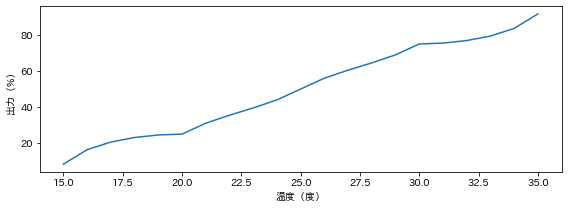

In [ ]:
power = []#グラフ描画用変数

for temp in x_temp:#設定した温度範囲を繰り返し文で調べる
  #温度のグレードの計算
  temp_level_lo2 = fuzz.interp_membership(x_temp, temp_lo2, temp)
  temp_level_lo = fuzz.interp_membership(x_temp, temp_lo, temp)
  temp_level_md = fuzz.interp_membership(x_temp, temp_md, temp)
  temp_level_hi = fuzz.interp_membership(x_temp, temp_hi, temp)
  temp_level_hi2 = fuzz.interp_membership(x_temp, temp_hi2, temp)
  #各グレードと出力のメンバシップ関数の小さい方の範囲を設定
  power_activation_lo2 = np.fmin(temp_level_lo2, power_lo2)
  power_activation_lo = np.fmin(temp_level_lo, power_lo)
  power_activation_md = np.fmin(temp_level_md, power_md)
  power_activation_hi = np.fmin(temp_level_hi, power_hi)
  power_activation_hi2 = np.fmin(temp_level_hi2, power_hi2)
  # すべての範囲を統合
  aggregated = np.fmax(power_activation_lo,
                     np.fmax(
                         np.fmax(power_activation_md, power_activation_hi),
                         np.fmax(power_activation_lo2, power_activation_hi2)))
  # 非ファジー化（出力の計算）
  now_power = fuzz.defuzz(x_power, aggregated, 'centroid')
  #グラフ用に値を保存
  power.append(now_power)

#可視化
fig, ax0 = plt.subplots(figsize=(8, 3))
ax0.set_xlabel("温度（度）")
ax0.set_ylabel("出力（%）")
ax0.plot(x_temp,power)
plt.tight_layout()


#ファジー制御

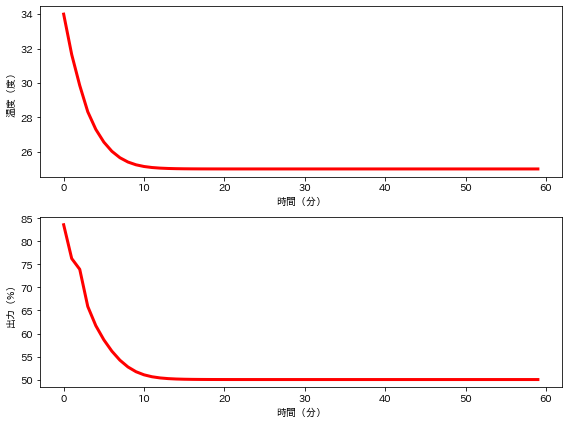

In [ ]:
init_temp = 34#初期温度の設定
T = 10
K = 1

time_range = np.arange(0,60,1)
now_temp = init_temp
temp = []#グラフ描画用変数（温度）
power = []#グラフ描画用変数（出力）

for ti in time_range:#設定した時間まで繰り返し文で調べる
  #温度の保存
  temp.append(now_temp)
  #温度のグレードの計算
  temp_level_lo2 = fuzz.interp_membership(x_temp, temp_lo2, now_temp)
  temp_level_lo = fuzz.interp_membership(x_temp, temp_lo, now_temp)
  temp_level_md = fuzz.interp_membership(x_temp, temp_md, now_temp)
  temp_level_hi = fuzz.interp_membership(x_temp, temp_hi, now_temp)
  temp_level_hi2 = fuzz.interp_membership(x_temp, temp_hi2, now_temp)
  #各グレードと出力のメンバシップ関数の小さい方の範囲を設定
  power_activation_lo2 = np.fmin(temp_level_lo2, power_lo2)
  power_activation_lo = np.fmin(temp_level_lo, power_lo)
  power_activation_md = np.fmin(temp_level_md, power_md)
  power_activation_hi = np.fmin(temp_level_hi, power_hi)
  power_activation_hi2 = np.fmin(temp_level_hi2, power_hi2)
  # すべての範囲を統合
  aggregated = np.fmax(power_activation_lo,
                     np.fmax(
                         np.fmax(power_activation_md, power_activation_hi),
                         np.fmax(power_activation_lo2, power_activation_hi2)))
  # 非ファジー化（出力の計算）
  now_power = fuzz.defuzz(x_power, aggregated, 'centroid')
  #出力つまみの値から実際の出力へ
  U=(100-now_power)/50*25
  #温度変化の計算
  now_temp =  (T*now_temp+K*U)/(1+T)
  #出力の保存
  power.append(now_power)

#可視化
fig, (ax0, ax1) = plt.subplots(nrows=2, figsize=(8, 6))
ax0.set_xlabel("時間（分）")
ax0.set_ylabel("温度（度）")
ax0.plot(time_range,temp, 'r', linewidth=3, linestyle="-")
ax1.set_xlabel("時間（分）")
ax1.set_ylabel("出力（%）")
ax1.plot(time_range,power, 'r', linewidth=3, linestyle="-")
plt.tight_layout()


#アニメーション（各時刻の画像の保存）

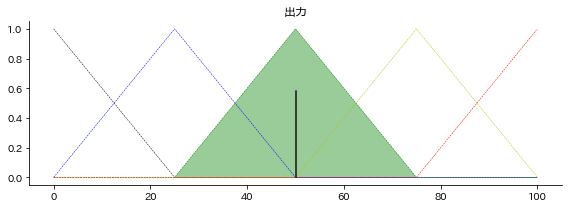

In [ ]:
init_temp = 34#初期温度の設定
T = 10
K = 1

time_range = np.arange(0,60,1)
now_temp = init_temp
temp = []#グラフ描画用変数（温度）
power = []#グラフ描画用変数（出力）

for ti in time_range:#設定した時間まで繰り返し文で調べる
  #温度の保存
  temp.append(now_temp)
  #温度のグレードの計算
  temp_level_lo2 = fuzz.interp_membership(x_temp, temp_lo2, now_temp)
  temp_level_lo = fuzz.interp_membership(x_temp, temp_lo, now_temp)
  temp_level_md = fuzz.interp_membership(x_temp, temp_md, now_temp)
  temp_level_hi = fuzz.interp_membership(x_temp, temp_hi, now_temp)
  temp_level_hi2 = fuzz.interp_membership(x_temp, temp_hi2, now_temp)
  #各グレードと出力のメンバシップ関数の小さい方の範囲を設定
  power_activation_lo2 = np.fmin(temp_level_lo2, power_lo2)
  power_activation_lo = np.fmin(temp_level_lo, power_lo)
  power_activation_md = np.fmin(temp_level_md, power_md)
  power_activation_hi = np.fmin(temp_level_hi, power_hi)
  power_activation_hi2 = np.fmin(temp_level_hi2, power_hi2)
  # すべての範囲を統合
  aggregated = np.fmax(power_activation_lo,
                     np.fmax(
                         np.fmax(power_activation_md, power_activation_hi),
                         np.fmax(power_activation_lo2, power_activation_hi2)))
  # 非ファジー化（出力の計算）
  now_power = fuzz.defuzz(x_power, aggregated, 'centroid')
  #出力つまみの値から実際の出力へ
  U=(100-now_power)/50*25
  #温度変化の計算
  now_temp =  (T*now_temp+K*U)/(1+T)
  #出力の保存
  power.append(now_power)

  # 可視化
  display.clear_output(wait=True)
  fig, ax0 = plt.subplots(figsize=(8, 3))

  ax0.fill_between(x_power, power0, power_activation_lo2, facecolor='k', alpha=0.4)
  ax0.plot(x_power, power_lo2, 'k', linewidth=0.5, linestyle='--', )
  ax0.fill_between(x_power, power0, power_activation_lo, facecolor='b', alpha=0.4)
  ax0.plot(x_power, power_lo, 'b', linewidth=0.5, linestyle='--', )
  ax0.fill_between(x_power, power0, power_activation_md, facecolor='g', alpha=0.4)
  ax0.plot(x_power, power_md, 'g', linewidth=0.5, linestyle='--')
  ax0.fill_between(x_power, power0, power_activation_hi, facecolor='y', alpha=0.4)
  ax0.plot(x_power, power_hi, 'y', linewidth=0.5, linestyle='--')
  ax0.fill_between(x_power, power0, power_activation_hi2, facecolor='r', alpha=0.4)
  ax0.plot(x_power, power_hi2, 'r', linewidth=0.5, linestyle='--')
  ax0.plot([now_power, now_power], [0, power_activation], 'k', linewidth=1.5, alpha=0.9)
  ax0.set_title('出力')

  # Turn off top/right axes
  for ax in (ax0,):
      ax.spines['top'].set_visible(False)
      ax.spines['right'].set_visible(False)
      ax.get_xaxis().tick_bottom()
      ax.get_yaxis().tick_left()
  plt.tight_layout()
  plt.savefig('image_at_{:04d}.png'.format(ti))
  plt.show()




#アニメーションの作成

In [ ]:
! pip install imageio

In [ ]:
import imageio
import glob

In [ ]:
anim_file = 'fuzzy.gif'
#anim_file = '/content/drive/MyDrive/dcgan.gif'

with imageio.get_writer(anim_file, mode='I') as writer:
  filenames = glob.glob('image*.png')
  filenames = sorted(filenames)
  print(filenames)
  for filename in filenames:
    image = imageio.imread(filename)
    writer.append_data(image)
  image = imageio.imread(filename)
  writer.append_data(image)

['image_at_0000.png', 'image_at_0001.png', 'image_at_0002.png', 'image_at_0003.png', 'image_at_0004.png', 'image_at_0005.png', 'image_at_0006.png', 'image_at_0007.png', 'image_at_0008.png', 'image_at_0009.png', 'image_at_0010.png', 'image_at_0011.png', 'image_at_0012.png', 'image_at_0013.png', 'image_at_0014.png', 'image_at_0015.png', 'image_at_0016.png', 'image_at_0017.png', 'image_at_0018.png', 'image_at_0019.png', 'image_at_0020.png', 'image_at_0021.png', 'image_at_0022.png', 'image_at_0023.png', 'image_at_0024.png', 'image_at_0025.png', 'image_at_0026.png', 'image_at_0027.png', 'image_at_0028.png', 'image_at_0029.png', 'image_at_0030.png', 'image_at_0031.png', 'image_at_0032.png', 'image_at_0033.png', 'image_at_0034.png', 'image_at_0035.png', 'image_at_0036.png', 'image_at_0037.png', 'image_at_0038.png', 'image_at_0039.png', 'image_at_0040.png', 'image_at_0041.png', 'image_at_0042.png', 'image_at_0043.png', 'image_at_0044.png', 'image_at_0045.png', 'image_at_0046.png', 'image_at_00

In [ ]:
! pip install git+https://github.com/tensorflow/docs

  Cloning https://github.com/tensorflow/docs to /tmp/pip-req-build-8iyy08k9
  Running command git clone -q https://github.com/tensorflow/docs /tmp/pip-req-build-8iyy08k9
  Created wheel for tensorflow-docs: filename=tensorflow_docs-0.0.0.dev0-py3-none-any.whl size=157864 sha256=7a58b92f80d8aa74ea0a58352aae0f3f733c9b679311b3d3ade99adf1dcd7c35
  Stored in directory: /tmp/pip-ephem-wheel-cache-lwi24cue/wheels/cc/c4/d8/5341e93b6376c5c929c49469fce21155eb69cef1a4da4ce32c
Successfully built tensorflow-docs


In [ ]:
import tensorflow_docs.vis.embed as embed

In [ ]:
embed.embed_file(anim_file)

#生成したファイルをgoogle driveのfuzzy_imageへ移動
fuzzy_imageフォルダをあらかじめ作成しておいてください
googleドライブをマウントしておいてください．（左上のアイコンでマウントできます）

コメントアウトを外すと実行できます．

In [ ]:
!mv image_at_*.png /content/drive/MyDrive/fuzzy_image/
!mv fuzzy.gif /content/drive/MyDrive/fuzzy_image/

#生成したファイルの削除
生成したimage_at_*.pngを削除できます．

コメントアウトを外すと実行できます．

In [ ]:
#!rm image_at_*.png